In [1]:
import pandas as pd
import numpy as np
import json
import ast
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

input_root = Path("/kaggle/input")

def find_one_file(filename, required=True):
    matches = sorted(input_root.rglob(filename))
    if not matches and required:
        raise FileNotFoundError(f"Add this Kaggle input file: {filename}")
    return matches[0] if matches else None

geoevent_path = find_one_file("geo_events_geoevent.csv")
geoevent_log_path = find_one_file("geo_events_geoeventchangelog.csv")
evaczone_path = find_one_file("evac_zones_gis_evaczone.csv")
evaczone_log_path = find_one_file("evac_zones_gis_evaczonechangelog.csv")
evac_map_path = find_one_file("evac_zone_status_geo_event_map.csv")
perimeter_path = find_one_file("fire_perimeters_gis_fireperimeter.csv")
acs_path = find_one_file("acs2017_county_data.csv", required=False)

print("Files ready.")

Files ready.


In [2]:
def safe_parse_json(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    text = str(value)
    try:
        return json.loads(text)
    except Exception:
        try:
            return ast.literal_eval(text)
        except Exception:
            return {}

def get_new_value(changes, key):
    changes = safe_parse_json(changes)
    if key not in changes:
        return np.nan
    value = changes[key]
    if isinstance(value, list) and len(value) >= 2:
        return value[1]
    return value

def present(value):
    if pd.isna(value):
        return False
    text = str(value).strip().lower()
    return text not in ["", "none", "nan", "false", "0"]

def pct_rank(series):
    return series.rank(pct=True).fillna(0)

In [3]:
geoevent_df = pd.read_csv(geoevent_path, dtype={"id": "string"}, low_memory=False)
geoevent_log_df = pd.read_csv(geoevent_log_path, dtype={"geo_event_id": "string"}, low_memory=False)
evaczone_df = pd.read_csv(evaczone_path, dtype={"id": "string", "uid_v2": "string"}, low_memory=False)
evaczone_log_df = pd.read_csv(evaczone_log_path, dtype={"evac_zone_id": "string"}, low_memory=False)
evac_map_df = pd.read_csv(evac_map_path, dtype={"uid_v2": "string", "geo_event_id": "string"}, low_memory=False)

for df, col in [
    (geoevent_df, "date_created"),
    (geoevent_log_df, "date_created"),
    (evaczone_log_df, "date_created"),
    (evac_map_df, "date_created"),
]:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

wildfire_df = geoevent_df[geoevent_df["geo_event_type"] == "wildfire"].copy()
wildfire_df["data_parsed"] = wildfire_df["data"].apply(safe_parse_json)
wildfire_df["acreage"] = wildfire_df["data_parsed"].apply(lambda x: x.get("acreage"))

print("Wildfires:", len(wildfire_df))

Wildfires: 61779


In [4]:
evaczone_log_df["new_status"] = evaczone_log_df["changes"].apply(lambda x: get_new_value(x, "status"))
evac_status = evaczone_log_df[evaczone_log_df["new_status"].apply(present)].copy()

evac_status["new_status"] = evac_status["new_status"].astype(str).str.lower()
evac_status = evac_status.sort_values("date_created")

first_zone_status = (
    evac_status
    .drop_duplicates("evac_zone_id", keep="first")
    .rename(columns={"date_created": "evac_status_time"})
)

evac_joined = first_zone_status.merge(
    evaczone_df[["id", "uid_v2", "display_name", "dataset_name"]],
    left_on="evac_zone_id",
    right_on="id",
    how="inner"
)

evac_joined = evac_joined.merge(
    evac_map_df[["uid_v2", "geo_event_id"]],
    on="uid_v2",
    how="inner"
)

evac_joined = evac_joined.merge(
    wildfire_df[["id", "name", "date_created", "lat", "lng", "acreage"]],
    left_on="geo_event_id",
    right_on="id",
    how="inner"
)

evac_joined = evac_joined.rename(columns={"date_created": "fire_created_time"})
evac_joined["evac_lag_minutes"] = (
    evac_joined["evac_status_time"] - evac_joined["fire_created_time"]
).dt.total_seconds() / 60

evac_analysis = evac_joined[
    evac_joined["evac_lag_minutes"].between(0, 7 * 24 * 60)
].copy()

first_evac_by_fire = (
    evac_analysis
    .sort_values("evac_status_time")
    .drop_duplicates("geo_event_id", keep="first")
    .copy()
)

print("Valid evac rows:", len(evac_analysis))
print("Fires with first evac action:", first_evac_by_fire["geo_event_id"].nunique())
display(first_evac_by_fire.sort_values("evac_lag_minutes", ascending=False).head(15))

Valid evac rows: 1467
Fires with first evac action: 216


,id_x,evac_status_time,changes,evac_zone_id,new_status,id_y,uid_v2,display_name,dataset_name,geo_event_id,id,name,fire_created_time,lat,lng,acreage,evac_lag_minutes
950,21322,2025-07-08 22:00:10.905637+00:00,"{""status"": [null, ""warnings""]}",21424,warnings,21424,shasta-CA_US-LKH-1448-2ffc05003651f20b,LKH-1448,shasta-CA_US,53571,53571,Green Fire,2025-07-02 16:27:37.676311+00:00,40.835159,-122.093756,19022.0,8972.553822
254,752,2025-05-19 20:54:33.555721+00:00,"{""status"": [null, ""orders""]}",29481,orders,29481,apache-AZ_US-Zone-1-8c664305794d4fd2,Zone 1,apache-AZ_US,48507,48507,Greer Fire,2025-05-13 18:01:11.801790+00:00,34.024832,-109.455316,20308.0,8813.362566
449,2655,2025-06-16 23:04:08.822281+00:00,"{""status"": [null, ""advisories""]}",32555,advisories,32555,grant-NM_US-10---Mimbres-b1060783da378b79,10 - Mimbres,grant-NM_US-trout,51304,51304,Trout Fire,2025-06-12 14:53:05.555820+00:00,32.979417,-108.232667,47294.0,6251.054441
927,21097,2025-07-07 15:59:18.214335+00:00,"{""status"": [null, ""orders""]}",31117,orders,31117,siskiyou-CA_US-SIS-1703-a42cf2165c993f3e,SIS-1703,siskiyou-CA_US,53945,53945,Butler Fire,2025-07-04 01:54:56.029080+00:00,41.313371,-123.414704,21058.0,5164.369754
1237,64402,2025-08-06 03:50:04.814301+00:00,"{""status"": [null, ""orders""]}",99558,orders,99558,rio_blanco-CO_US-ZONE-1-b6e96f6ea131ad33,ZONE 1,rio_blanco-CO_US,58374,58374,Elk RBX Fire,2025-08-02 19:04:16.173167+00:00,39.959444,-107.745278,14518.0,4845.810686
1229,64394,2025-08-06 03:45:50.841287+00:00,"{""status"": [null, ""orders""]}",99552,orders,99552,rio_blanco-CO_US-ZONE-20-4fbb8b343af4cbcf,ZONE 20,rio_blanco-CO_US,58471,58471,Lee Fire,2025-08-03 00:06:12.148213+00:00,39.933850,-108.234010,137758.0,4539.644885
1076,28651,2025-07-16 23:38:21.081729+00:00,"{""status"": [null, ""warnings""]}",60676,warnings,60676,la_plata-CO_US-UTE63-1-db3e9043507fcd44,UTE63-1,la_plata-CO_US,55714,55714,Ute 63 Fire,2025-07-14 02:23:39.398277+00:00,37.025250,-108.255465,529.6,4154.694724
1017,28475,2025-07-13 03:09:42.940931+00:00,"{""status"": [null, ""orders""]}",60426,orders,60426,montrose-CO_US-ZONE-1-4107605a906065bf,ZONE 1,montrose-CO_US-south-rim,55281,55281,South Rim Fire,2025-07-10 18:11:00.280140+00:00,38.558100,-107.719167,4232.0,3418.711013
786,10577,2025-07-01 05:20:24.494256+00:00,"{""status"": [null, ""warnings""]}",42252,warnings,42252,apache-AZ_US-East-Route-12-d5aa1521c6d312d7,East Route 12,apache-AZ_US,52994,52994,Oak Ridge Fire,2025-06-28 20:43:14.583231+00:00,35.600693,-109.171031,11027.5,3397.165184
1167,63090,2025-07-31 22:08:38.668349+00:00,"{""status"": [null, ""orders""]}",98317,orders,98317,malheur-OR_US-MAH-E059-C-5a86a2a1d4f16f22,MAH-E059-C,malheur-OR_US,57617,57617,Rock Creek Fire,2025-07-30 03:03:14.071229+00:00,42.855667,-117.328773,31192.0,2585.409952


In [5]:
danger_keys = {
    "rate_of_spread_signal": "radio_traffic_indicates_rate_of_spread",
    "structure_threat_signal": "radio_traffic_indicates_structure_threat",
    "spotting_signal": "radio_traffic_indicates_spotting",
}

for out_col, key in danger_keys.items():
    geoevent_log_df[out_col] = geoevent_log_df["changes"].apply(lambda x: get_new_value(x, key))

danger_rows = geoevent_log_df[
    geoevent_log_df[list(danger_keys.keys())].apply(lambda row: any(present(v) for v in row), axis=1)
].copy()

danger_summary = (
    danger_rows
    .sort_values("date_created")
    .groupby("geo_event_id")
    .agg(first_danger_signal_time=("date_created", "min"))
    .reset_index()
)

first_evac_with_danger = first_evac_by_fire.merge(danger_summary, on="geo_event_id", how="left")

first_evac_with_danger["danger_before_evac"] = (
    first_evac_with_danger["first_danger_signal_time"].notna()
    & (first_evac_with_danger["first_danger_signal_time"] <= first_evac_with_danger["evac_status_time"])
)

first_evac_with_danger["danger_to_evac_minutes"] = np.where(
    first_evac_with_danger["danger_before_evac"],
    (first_evac_with_danger["evac_status_time"] - first_evac_with_danger["first_danger_signal_time"]).dt.total_seconds() / 60,
    0
)

first_evac_with_danger["potential_lead_time_gain"] = (
    first_evac_with_danger["danger_to_evac_minutes"] - 30
).clip(lower=0)

display(first_evac_with_danger["danger_before_evac"].value_counts())

danger_before_evac
True     121
False     95
Name: count, dtype: int64

In [6]:
perimeter_df = pd.read_csv(
    perimeter_path,
    usecols=["geo_event_id", "date_created", "approval_status", "source_acres"],
    dtype={"geo_event_id": "string"},
    low_memory=False
)

perimeter_df["date_created"] = pd.to_datetime(perimeter_df["date_created"], errors="coerce", utc=True)
perimeter_df["source_acres"] = pd.to_numeric(perimeter_df["source_acres"], errors="coerce")

perimeter_summary = (
    perimeter_df[perimeter_df["approval_status"].astype(str).str.lower() == "approved"]
    .groupby("geo_event_id")
    .agg(max_perimeter_acres=("source_acres", "max"))
    .reset_index()
)

dashboard = first_evac_with_danger.merge(perimeter_summary, on="geo_event_id", how="left")
dashboard["size_acres"] = dashboard["max_perimeter_acres"].fillna(pd.to_numeric(dashboard["acreage"], errors="coerce"))

status_score = {
    "orders": 1.00,
    "shelter_in_place": 0.90,
    "warnings": 0.75,
    "advisories": 0.50,
}

dashboard["lag_score"] = pct_rank(dashboard["evac_lag_minutes"])
dashboard["danger_gap_score"] = np.where(
    dashboard["potential_lead_time_gain"] > 0,
    pct_rank(dashboard["potential_lead_time_gain"]),
    0
)
dashboard["status_score"] = dashboard["new_status"].map(status_score).fillna(0.50)
dashboard["size_score"] = pct_rank(dashboard["size_acres"])

print("Base dashboard ready.")

Base dashboard ready.


In [7]:
def county_from_dataset_name(name):
    text = str(name)
    if "-CA_US" not in text:
        return np.nan
    county = text.split("-CA_US")[0]
    return county.replace("_", " ").title()

ca_dashboard = dashboard[
    dashboard["lat"].between(32.4, 42.1)
    & dashboard["lng"].between(-124.6, -114.0)
    & dashboard["dataset_name"].astype(str).str.contains("-CA_US", na=False)
].copy()

ca_dashboard["county_name"] = ca_dashboard["dataset_name"].apply(county_from_dataset_name)

if acs_path is None:
    print("Add ACS county data to Kaggle for equity scoring.")
    ca_dashboard["vulnerability_score"] = 0
    ca_dashboard["language_access_signal"] = False
else:
    census = pd.read_csv(acs_path)
    ca_census = census[census["State"] == "California"].copy()
    ca_census["county_name"] = ca_census["County"].str.replace(" County", "", regex=False)

    ca_dashboard = ca_dashboard.merge(
        ca_census[
            ["county_name", "TotalPop", "IncomePerCap", "Poverty", "ChildPoverty",
             "Hispanic", "Transit", "Unemployment"]
        ],
        on="county_name",
        how="left"
    )

    county_equity = (
        ca_dashboard
        .groupby("county_name")
        .agg(
            fires=("geo_event_id", "nunique"),
            median_lag=("evac_lag_minutes", "median"),
            IncomePerCap=("IncomePerCap", "first"),
            Poverty=("Poverty", "first"),
            ChildPoverty=("ChildPoverty", "first"),
            Hispanic=("Hispanic", "first"),
            Transit=("Transit", "first"),
            Unemployment=("Unemployment", "first"),
        )
        .reset_index()
    )

    county_equity["vulnerability_score"] = pd.concat([
        pct_rank(county_equity["Poverty"]),
        pct_rank(county_equity["ChildPoverty"]),
        pct_rank(county_equity["Unemployment"]),
        pct_rank(county_equity["Transit"]),
        pct_rank(-county_equity["IncomePerCap"]),
    ], axis=1).mean(axis=1)

    ca_dashboard = ca_dashboard.merge(
        county_equity[["county_name", "vulnerability_score"]],
        on="county_name",
        how="left"
    )

    ca_dashboard["language_access_signal"] = ca_dashboard["Hispanic"] >= 30

display(ca_dashboard.head())

,id_x,evac_status_time,changes,evac_zone_id,new_status,id_y,uid_v2,display_name,dataset_name,geo_event_id,id,name,fire_created_time,lat,lng,acreage,evac_lag_minutes,first_danger_signal_time,danger_before_evac,danger_to_evac_minutes,potential_lead_time_gain,max_perimeter_acres,size_acres,lag_score,danger_gap_score,status_score,size_score,county_name,TotalPop,IncomePerCap,Poverty,ChildPoverty,Hispanic,Transit,Unemployment,vulnerability_score,language_access_signal
0,173,2025-04-25 08:24:47.806405+00:00,"{""status"": [null, ""orders""]}",28525,orders,28525,riverside-CA_US-RVC-1922-B-f3ff1704eabfdc98,RVC-1922-B,riverside-CA_US,46945,46945,Church Fire,2025-04-25 05:23:52.073454+00:00,33.634780,-116.139930,50.0,180.928883,2025-04-25 05:33:34.418236+00:00,True,171.223136,141.223136,NaN,50.000000,0.777778,0.898148,1.00,0.466667,Riverside,2355002,25700,15.6,21.3,48.0,1.3,9.9,0.597059,True
1,682,2025-05-15 23:46:09.691162+00:00,"{""status"": [null, ""warnings""]}",16491,warnings,16491,riverside-CA_US-RVC-1896-c157ba02adf9cae8,RVC-1896,riverside-CA_US,48694,48694,Baxter Fire,2025-05-15 22:39:21.485561+00:00,33.609978,-117.149563,59.5,66.803427,2025-05-15 22:39:21.549943+00:00,True,66.802354,36.802354,58.508098,58.508098,0.509259,0.773148,0.75,0.519048,Riverside,2355002,25700,15.6,21.3,48.0,1.3,9.9,0.597059,True
2,767,2025-05-20 05:37:45.868805+00:00,"{""status"": [null, ""warnings""]}",22504,warnings,22504,siskiyou-CA_US-MTS-6155-8f4c98b73b8de2a4,MTS-6155,siskiyou-CA_US,48941,48941,Spring Fire,2025-05-20 04:09:44.165815+00:00,41.333959,-122.329255,12.0,88.028383,2025-05-20 04:09:44.551736+00:00,True,88.021951,58.021951,NaN,12.000000,0.601852,0.824074,0.75,0.238095,Siskiyou,43530,24605,20.7,26.6,12.0,0.7,9.1,0.644118,False
3,1103,2025-05-20 22:30:35.755255+00:00,"{""status"": [null, ""warnings""]}",16567,warnings,16567,riverside-CA_US-RVC-TULE1-132764a175c3a882,RVC-TULE1,riverside-CA_US,48977,48977,Crossing Fire,2025-05-20 20:44:28.438178+00:00,33.466728,-116.827736,126.0,106.121951,2025-05-20 20:55:37.527711+00:00,True,94.970459,64.970459,112.000849,112.000849,0.657407,0.837963,0.75,0.595238,Riverside,2355002,25700,15.6,21.3,48.0,1.3,9.9,0.597059,True
4,1192,2025-05-23 00:39:23.675856+00:00,"{""status"": [null, ""orders""]}",12454,orders,12454,mono-CA_US-MCU-E023-7ba3c556b5a014ab,MCU-E023,mono-CA_US,49168,49168,Inn Fire,2025-05-22 22:51:51.854753+00:00,38.009312,-119.156506,728.0,107.530352,2025-05-28 16:58:15.471379+00:00,False,0.000000,0.000000,727.524003,727.524003,0.662037,0.000000,1.00,0.766667,Mono,14058,30888,9.9,12.0,27.1,19.7,3.6,0.329412,False


In [8]:
ca_dashboard["priority_score"] = (
    0.35 * ca_dashboard["lag_score"]
    + 0.25 * ca_dashboard["danger_gap_score"]
    + 0.25 * ca_dashboard["vulnerability_score"].fillna(0)
    + 0.10 * ca_dashboard["status_score"]
    + 0.05 * ca_dashboard["size_score"]
)

def recommend_action(row):
    actions = []
    if row["potential_lead_time_gain"] > 30:
        actions.append("review trigger earlier")
    if row["vulnerability_score"] >= 0.70:
        actions.append("prioritize outreach")
    if row.get("language_access_signal", False):
        actions.append("send bilingual message")
    if row["new_status"] == "orders":
        actions.append("check transport needs")
    if not actions:
        actions.append("monitor closely")
    return "; ".join(actions)

ca_dashboard["recommended_action"] = ca_dashboard.apply(recommend_action, axis=1)

equity_priority_dashboard = ca_dashboard[
    ["name", "county_name", "display_name", "new_status", "evac_lag_minutes",
     "danger_before_evac", "potential_lead_time_gain", "vulnerability_score",
     "language_access_signal", "priority_score", "recommended_action"]
].sort_values("priority_score", ascending=False)

display(equity_priority_dashboard.head(20))

print("Estimated minutes gained for top 20:")
print(round(equity_priority_dashboard.head(20)["potential_lead_time_gain"].sum(), 1))

,name,county_name,display_name,new_status,evac_lag_minutes,danger_before_evac,potential_lead_time_gain,vulnerability_score,language_access_signal,priority_score,recommended_action
137,Salt/14-2 Fire,Fresno,P25,orders,1250.802519,True,1187.777720,0.847059,True,0.917003,review trigger earlier; prioritize outreach; send bilingual message; check transport needs
118,Garnet Fire,Fresno,K27,orders,572.733884,True,346.748132,0.847059,True,0.903855,review trigger earlier; prioritize outreach; send bilingual message; check transport needs
69,Butler Fire,Siskiyou,SIS-1703,orders,5164.369754,True,3832.909292,0.644118,False,0.900553,review trigger earlier; check transport needs
115,Little Fire,Kern,KRN-708,warnings,1360.259614,True,1330.259289,0.805882,True,0.882502,review trigger earlier; prioritize outreach; send bilingual message
20,Ranch Fire,San Bernardino,ONFLY_15901356-0,orders,375.244203,True,328.435842,0.729412,True,0.860422,review trigger earlier; prioritize outreach; send bilingual message; check transport needs
78,Max Fire,Fresno,K61,warnings,302.009195,True,198.754519,0.847059,True,0.841441,review trigger earlier; prioritize outreach; send bilingual message
70,Green Fire,Shasta,LKH-1448,warnings,8972.553822,True,8508.439366,0.476471,False,0.840103,review trigger earlier
51,Lake Fire,San Bernardino,ONFLY_16054616-0,orders,238.709711,True,201.095817,0.729412,True,0.829655,review trigger earlier; prioritize outreach; send bilingual message; check transport needs
26,Dogs Fire,Kern,KRN-600,warnings,194.047330,True,164.046540,0.805882,True,0.821451,review trigger earlier; prioritize outreach; send bilingual message
58,Summit Fire,Siskiyou,SIS-1414,orders,272.426783,True,242.426006,0.644118,False,0.817412,review trigger earlier; check transport needs


Estimated minutes gained for top 20:
18894.7


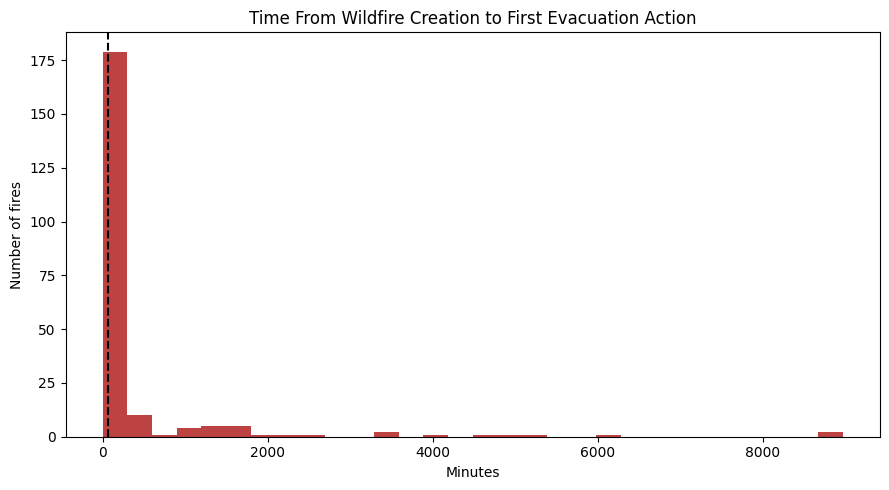

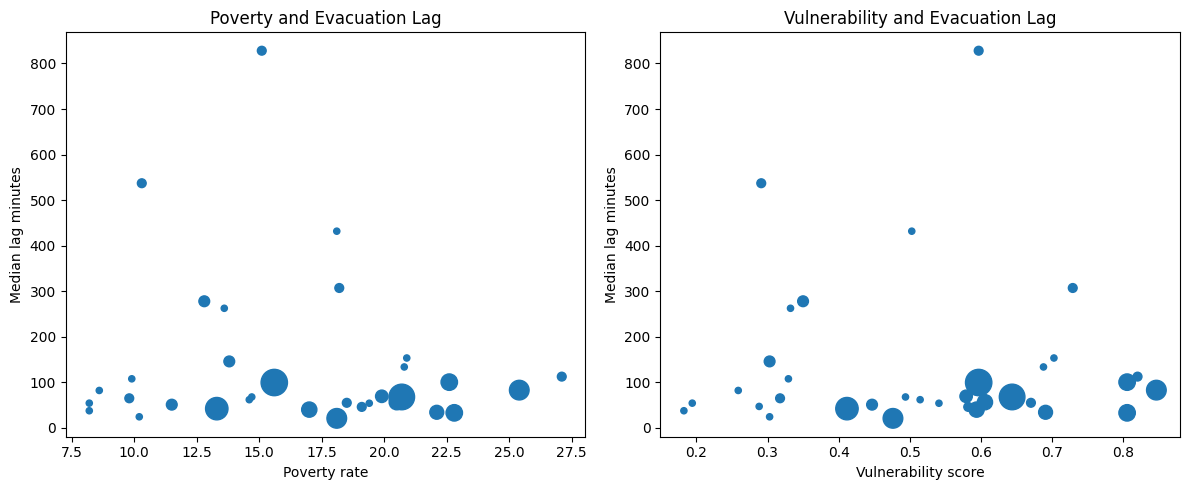

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(first_evac_by_fire["evac_lag_minutes"], bins=30, color="firebrick", alpha=0.85)
plt.axvline(first_evac_by_fire["evac_lag_minutes"].median(), color="black", linestyle="--")
plt.title("Time From Wildfire Creation to First Evacuation Action")
plt.xlabel("Minutes")
plt.ylabel("Number of fires")
plt.tight_layout()
plt.show()

if "county_equity" in globals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(county_equity["Poverty"], county_equity["median_lag"], s=county_equity["fires"] * 20)
    axes[0].set_title("Poverty and Evacuation Lag")
    axes[0].set_xlabel("Poverty rate")
    axes[0].set_ylabel("Median lag minutes")

    axes[1].scatter(county_equity["vulnerability_score"], county_equity["median_lag"], s=county_equity["fires"] * 20)
    axes[1].set_title("Vulnerability and Evacuation Lag")
    axes[1].set_xlabel("Vulnerability score")
    axes[1].set_ylabel("Median lag minutes")

    plt.tight_layout()
    plt.show()

Wolf Fire case study
County: Riverside
Evac zones: 1
Median lag minutes: 160.4
Max lag minutes: 160.4
Median vulnerability: 0.6


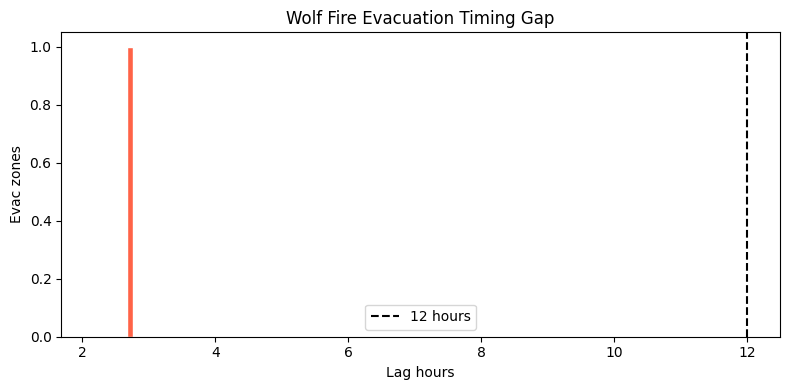

In [10]:
wolf = ca_dashboard[ca_dashboard["name"].astype(str).str.contains("Wolf Fire", case=False, na=False)].copy()

if len(wolf) == 0:
    print("Wolf Fire was not found in the filtered data.")
else:
    print("Wolf Fire case study")
    print("County:", wolf["county_name"].iloc[0])
    print("Evac zones:", len(wolf))
    print("Median lag minutes:", round(wolf["evac_lag_minutes"].median(), 1))
    print("Max lag minutes:", round(wolf["evac_lag_minutes"].max(), 1))
    print("Median vulnerability:", round(wolf["vulnerability_score"].median(), 2))

    plt.figure(figsize=(8, 4))
    plt.hist(wolf["evac_lag_minutes"] / 60, bins=12, color="tomato", edgecolor="white")
    plt.axvline(12, color="black", linestyle="--", label="12 hours")
    plt.title("Wolf Fire Evacuation Timing Gap")
    plt.xlabel("Lag hours")
    plt.ylabel("Evac zones")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
# Cell 11: Find counties where vulnerability and lag overlap

# Keep counties with enough fire cases
reliable_counties = county_equity[county_equity["fires"] >= 3].copy()

# Use median lines to define high-priority counties
lag_cutoff = reliable_counties["median_lag"].median()
vulnerability_cutoff = reliable_counties["vulnerability_score"].median()

# Flag counties that are high on both delay and vulnerability
reliable_counties["equity_priority_group"] = np.where(
    (reliable_counties["median_lag"] >= lag_cutoff) &
    (reliable_counties["vulnerability_score"] >= vulnerability_cutoff),
    "High vulnerability + high lag",
    "Other"
)

# Show the counties with the strongest overlap first
display(
    reliable_counties
    .sort_values(["equity_priority_group", "median_lag"], ascending=[True, False])
)

,county_name,fires,median_lag,IncomePerCap,Poverty,ChildPoverty,Hispanic,Transit,Unemployment,vulnerability_score,equity_priority_group
6,Kern,7,100.220808,21716,22.6,31.3,52.2,0.9,10.9,0.805882,High vulnerability + high lag
19,Riverside,18,99.379023,25700,15.6,21.3,48.0,1.3,9.9,0.597059,High vulnerability + high lag
3,Fresno,10,82.694305,22234,25.4,36.5,52.4,1.2,10.4,0.847059,High vulnerability + high lag
25,Siskiyou,17,67.677322,24605,20.7,26.6,12.0,0.7,9.1,0.644118,High vulnerability + high lag
1,Calaveras,3,277.811068,31652,12.8,18.9,11.5,1.0,7.1,0.350000,Other
22,San Luis Obispo,3,145.748486,33972,13.8,12.9,22.2,1.4,4.8,0.302941,Other
28,Trinity,4,69.141804,23575,19.9,24.5,7.2,0.1,9.6,0.579412,Other
0,Butte,6,56.175262,26304,20.5,21.5,15.7,1.2,9.1,0.605882,Other
26,Solano,3,50.767931,31934,11.5,16.6,25.8,3.0,8.5,0.447059,Other
21,San Diego,13,42.003623,34350,13.3,17.1,33.4,3.1,7.1,0.411765,Other


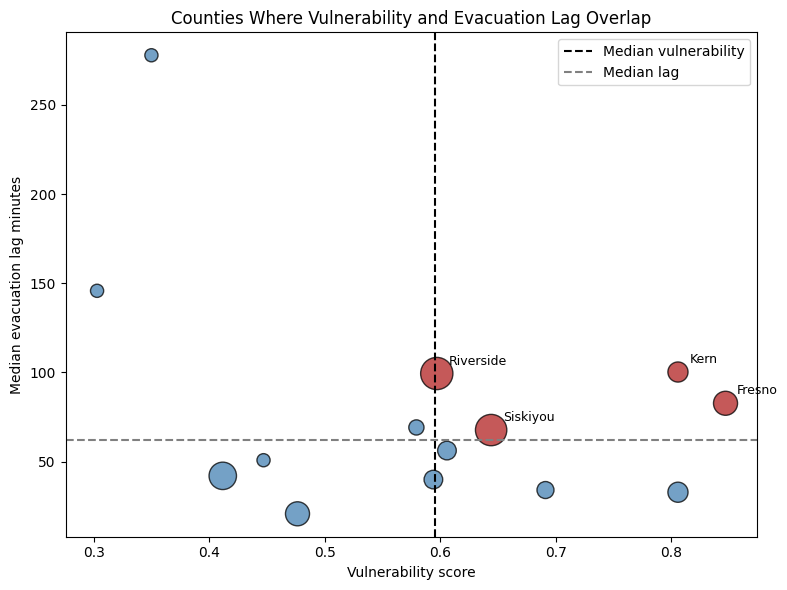

In [12]:
# Cell 12: Plot counties where vulnerability and lag overlap

plt.figure(figsize=(8, 6))

# Use red for counties with both high vulnerability and high lag
colors = reliable_counties["equity_priority_group"].map({
    "High vulnerability + high lag": "firebrick",
    "Other": "steelblue"
})

# Bubble size shows how many fires were measured
plt.scatter(
    reliable_counties["vulnerability_score"],
    reliable_counties["median_lag"],
    s=reliable_counties["fires"] * 30,
    c=colors,
    alpha=0.75,
    edgecolor="black"
)

# Add cutoff lines
plt.axvline(vulnerability_cutoff, color="black", linestyle="--", label="Median vulnerability")
plt.axhline(lag_cutoff, color="gray", linestyle="--", label="Median lag")

# Label only priority counties
for _, row in reliable_counties.iterrows():
    if row["equity_priority_group"] == "High vulnerability + high lag":
        plt.text(
            row["vulnerability_score"] + 0.01,
            row["median_lag"] + 5,
            row["county_name"],
            fontsize=9
        )

plt.title("Counties Where Vulnerability and Evacuation Lag Overlap")
plt.xlabel("Vulnerability score")
plt.ylabel("Median evacuation lag minutes")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Cell 13: Build an action table for equity-priority counties

# Keep only counties with both high vulnerability and high lag
equity_priority_counties = reliable_counties[
    reliable_counties["equity_priority_group"] == "High vulnerability + high lag"
].copy()

# Create simple action recommendations
def county_action(row):
    actions = []

    if row["Hispanic"] >= 30:
        actions.append("bilingual alerts")

    if row["Transit"] >= reliable_counties["Transit"].median():
        actions.append("transport support")

    if row["Poverty"] >= reliable_counties["Poverty"].median():
        actions.append("community outreach")

    if row["median_lag"] >= reliable_counties["median_lag"].quantile(0.75):
        actions.append("earlier trigger review")

    return "; ".join(actions)

equity_priority_counties["recommended_support"] = equity_priority_counties.apply(county_action, axis=1)

# Show the pilot counties
display(
    equity_priority_counties[
        ["county_name", "fires", "median_lag", "vulnerability_score",
         "Poverty", "ChildPoverty", "Hispanic", "Transit",
         "recommended_support"]
    ].sort_values("priority_score" if "priority_score" in equity_priority_counties.columns else "median_lag", ascending=False)
)

,county_name,fires,median_lag,vulnerability_score,Poverty,ChildPoverty,Hispanic,Transit,recommended_support
6,Kern,7,100.220808,0.805882,22.6,31.3,52.2,0.9,bilingual alerts; community outreach; earlier trigger review
19,Riverside,18,99.379023,0.597059,15.6,21.3,48.0,1.3,bilingual alerts; transport support; earlier trigger review
3,Fresno,10,82.694305,0.847059,25.4,36.5,52.4,1.2,bilingual alerts; transport support; community outreach
25,Siskiyou,17,67.677322,0.644118,20.7,26.6,12.0,0.7,community outreach
